# 1. Import Depedencies

In [9]:
from google.colab import drive
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Load Citra

In [64]:
DRIVE_IMG_DIR = "/content/drive/MyDrive/Tugas/Ilmu_Komputer/Semester_3/PCD/Assignment02/images"

# noisy
dataset_paths_noisy = {
  "noisy_image": os.path.join(DRIVE_IMG_DIR, "noisy_image.jpg"),
  "noisy_image2": os.path.join(DRIVE_IMG_DIR, "noisy_image2.jpg"),
  "noisy_image3": os.path.join(DRIVE_IMG_DIR, "noisy_image3.jpg"),
}

# blurry
dataset_paths_blurred = {
    "blurred_image": os.path.join(DRIVE_IMG_DIR, "blurred_image.jpg"),
    "blurred_image2": os.path.join(DRIVE_IMG_DIR, "blurred_image2.jpg"),
    "blurred_image3": os.path.join(DRIVE_IMG_DIR, "blurred_image3.jpg"),
}

# Noisy Handling With Median Filter and Averaging filter

Load citra noisy

In [65]:
images_gray = {}
images_float = {}

for noise_type, file_path in dataset_paths_noisy.items():
  img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
  if img is None:
    raise FileNotFoundError(f"gagal memuat {noise_type}")
  images_gray[noise_type] = img
  images_float[noise_type] = img.astype(np.float32)
  print(f"[{noise_type}] berhasil dimuat: {img.shape[0]}x{img.shape[1]} piksel")

[noisy_image] berhasil dimuat: 321x481 piksel
[noisy_image2] berhasil dimuat: 321x481 piksel
[noisy_image3] berhasil dimuat: 321x481 piksel


# 3. Zero Padding (Spatial 2D)

In [66]:
def manual_zero_pad(image: np.ndarray, pad_size: int = 1) -> np.ndarray:
  h, w = image.shape
  # buat kanvas kosong berisi nilai 0
  padded = np.zeros((h + 2 * pad_size, w + 2 * pad_size), dtype=np.float32)
  # tempatkan citra asli di tengahh
  padded[pad_size:h + pad_size, pad_size:w + pad_size] = image
  return padded

# 4. Averaging Filter (Mean Filter 3x3)

In [67]:
def manual_averaging_filter(image: np.ndarray, kernel_size: int = 3) -> np.ndarray:
  h, w = image.shape
  pad_size = kernel_size // 2

  # terapkan zero-padding
  padded_img = manual_zero_pad(image, pad_size=pad_size)

  # matriks penampung output dengan dimensi yang sama persis seperti citra asli
  output = np.zeros((h, w), dtype=np.float32)
  total_weights = kernel_size * kernel_size

  # nested loop melintasi setiap piksel citra asli
  for i in range(h):
    for j in range(w):
      # ekstrak jendela tetangga berukuran kernel_size x kernel_size
      window = padded_img[i : i + kernel_size, j : j + kernel_size]
      window_sum = np.sum(window)
      output[i, j] = window_sum / total_weights

    # pembulatan desimal terdekat sebelum dikonversi kembali ke uint8
  return np.round(output).astype(np.uint8)

# 5. Median Filter (3x3)

In [68]:
def manual_median_filter(image: np.ndarray, kernel_size: int = 3) -> np.ndarray:
  h, w = image.shape
  pad_size = kernel_size // 2

  # terapkan zero-padding
  padded_img = manual_zero_pad(image, pad_size=pad_size)

  # matriks penampung output
  output = np.zeros((h, w), dtype=np.float32)

  # indeks nilai tengah, indeks tengah adalah indeks ke-4 di kernel 3x3
  median_idx = (kernel_size * kernel_size) // 2

  # nested loop melintasi setiap piksel citra asli
  for i in range(h):
    for j in range(w):
      window = padded_img[i : i + kernel_size, j : j + kernel_size]
      window_flat = window.flatten()
      sorted_window = np.sort(window_flat)
      output[i, j] = sorted_window[median_idx]

  return output.astype(np.uint8)

# 6. Batch Noise Handling Filtering

In [69]:
results = {}

for noise_type, img_flt in images_float.items():
  # eksekusi manual avg filtering
  t0 = time.time()
  res_avg = manual_averaging_filter(img_flt, kernel_size=3)
  t_avg = time.time() - t0
  print(f"-> Averaging Filter: {t_avg:.2f} detik")

  # eksekusi manual median filtering
  t0 = time.time()
  res_med = manual_median_filter(img_flt, kernel_size=3)
  t_med = time.time() - t0
  print(f"-> Median Filter   : {t_med:.2f} detik")

  # Simpan hasil pemfilteran dan durasi komputasi
  results[noise_type] = {
    "avg": res_avg,
    "med": res_med,
    "time_avg": t_avg,
    "time_med": t_med
  }

-> Averaging Filter: 1.10 detik
-> Median Filter   : 0.79 detik
-> Averaging Filter: 1.07 detik
-> Median Filter   : 1.05 detik
-> Averaging Filter: 0.84 detik
-> Median Filter   : 0.45 detik


# 7. Visualisasi hasil noisy

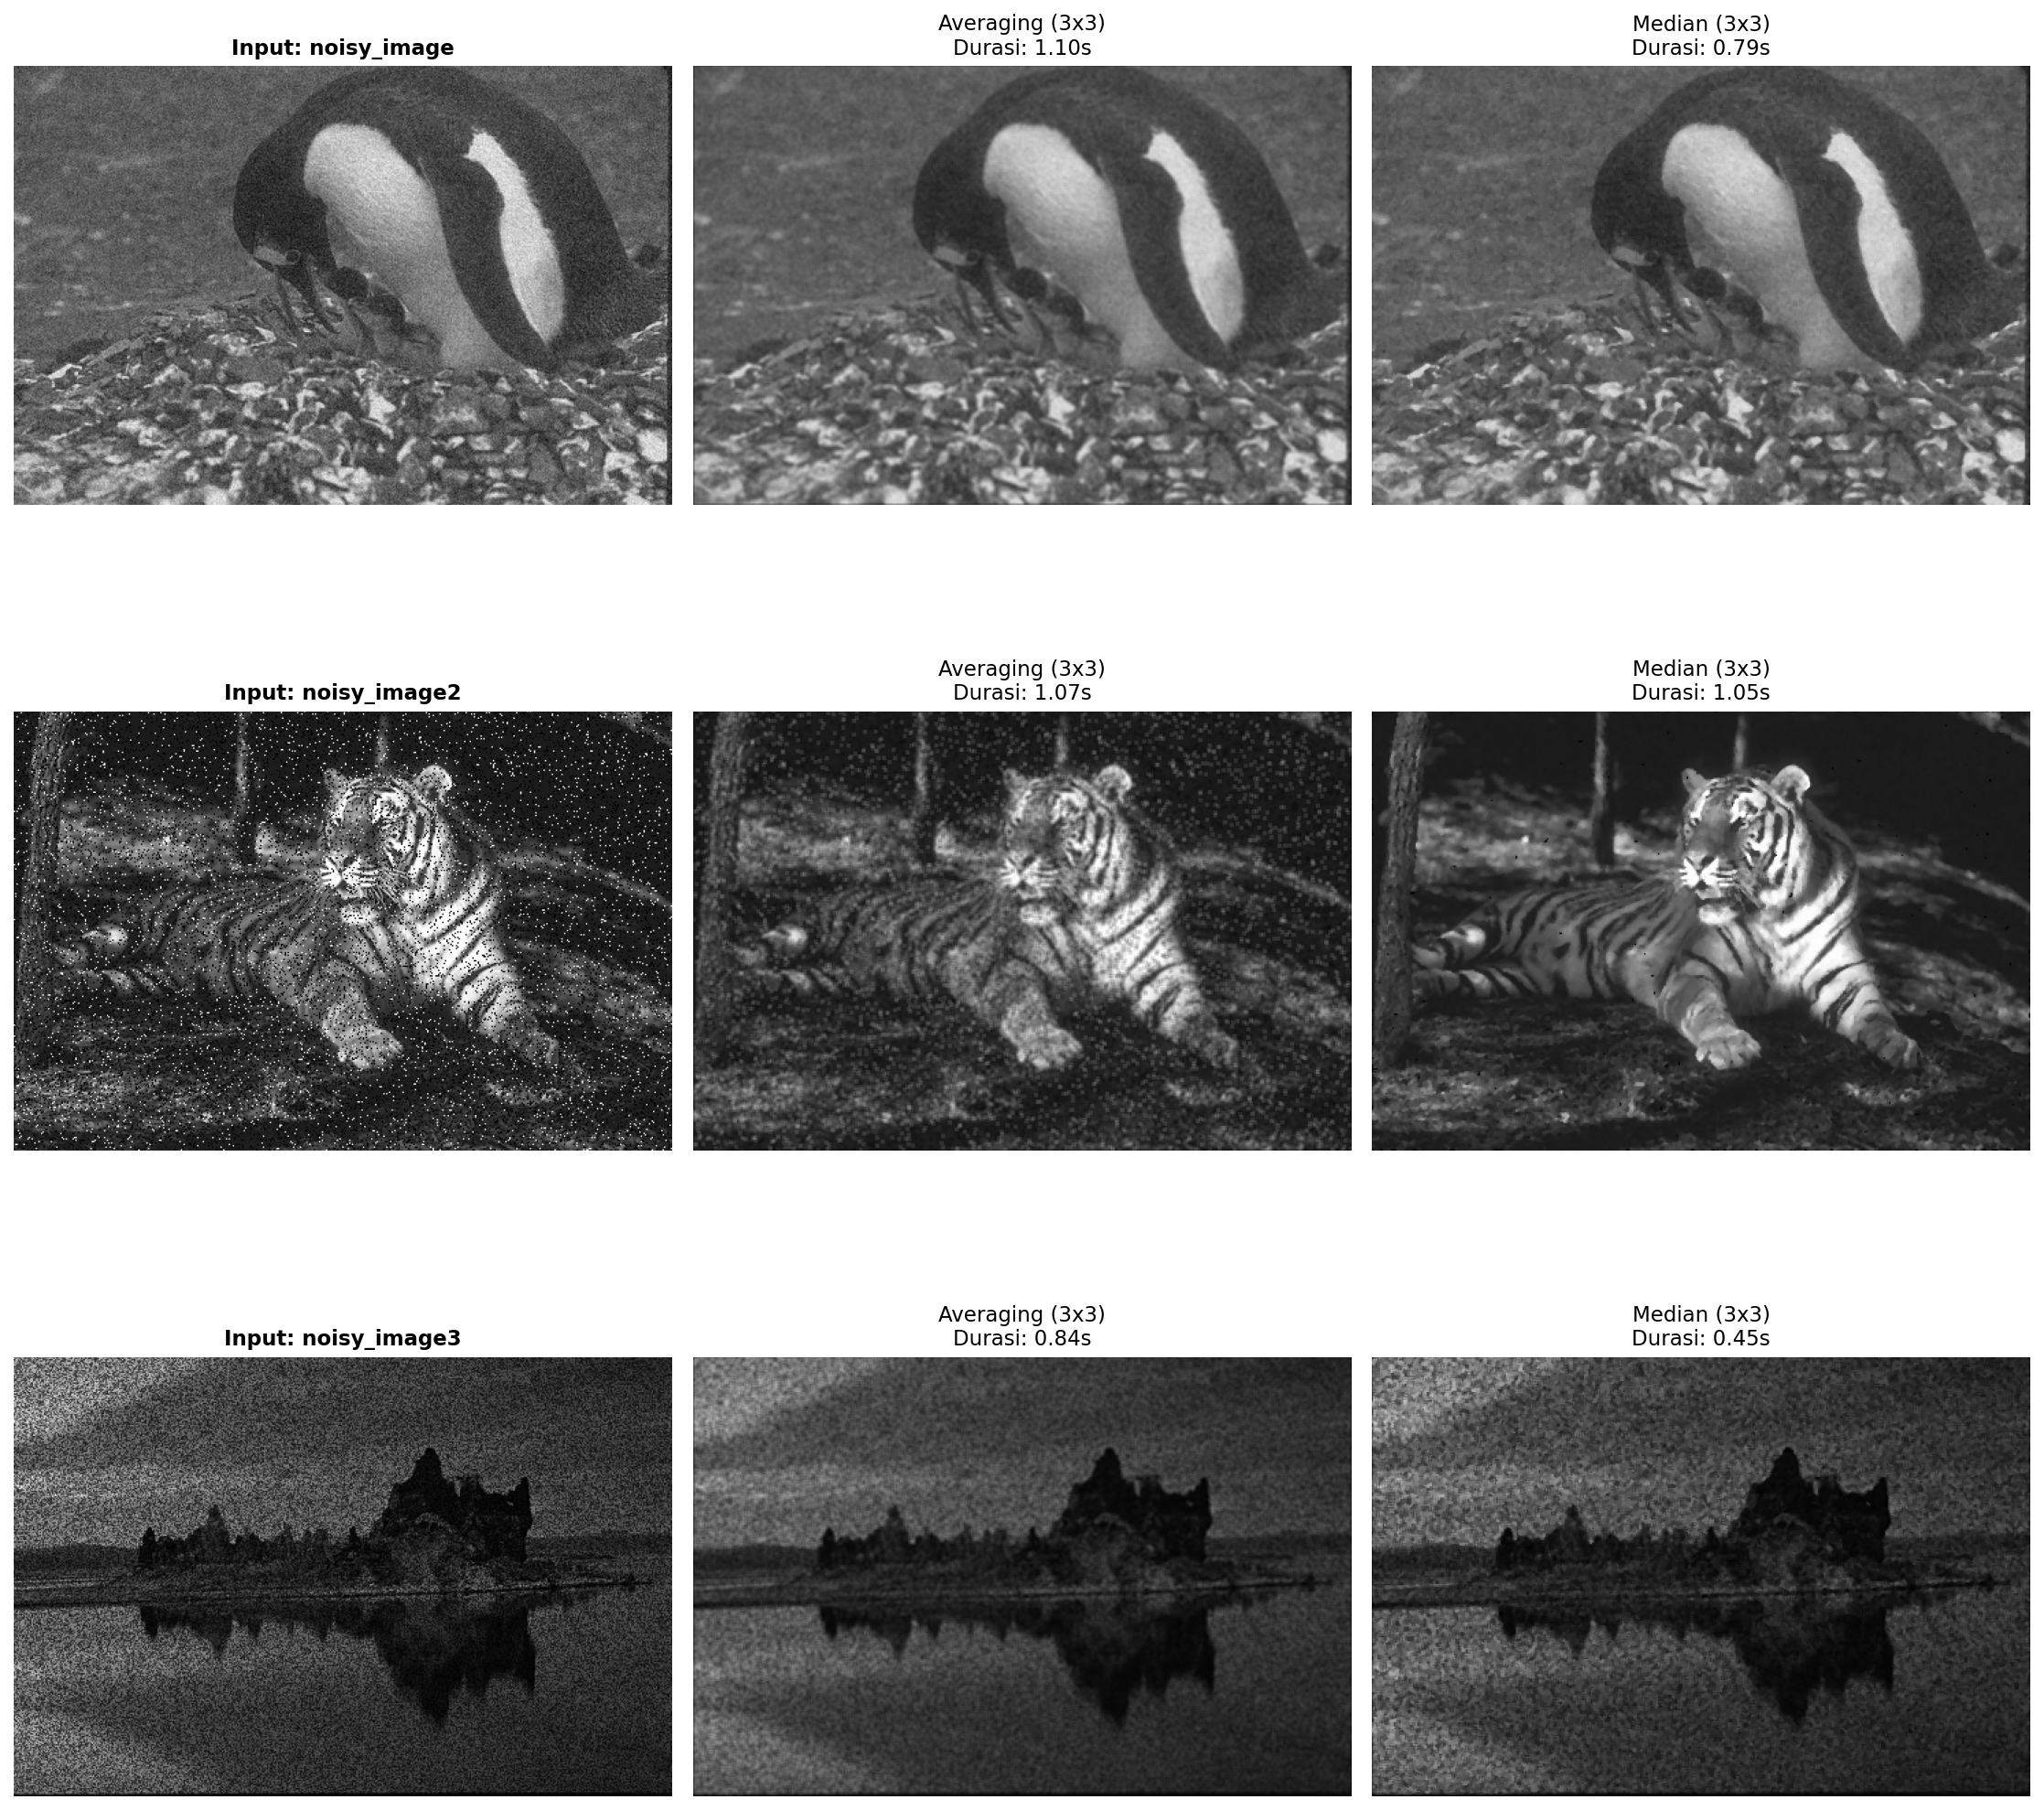

In [70]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15), dpi=150)
noise_keys = list(dataset_paths_noisy.keys())

for row_idx, noise_name in enumerate(noise_keys):
  orig = images_gray[noise_name]
  avg_img = results[noise_name]["avg"]
  med_img = results[noise_name]["med"]
  t_avg = results[noise_name]["time_avg"]
  t_med = results[noise_name]["time_med"]

  # Kolom 1: Citra Asli Ber-noise
  axes[row_idx, 0].imshow(orig, cmap='gray', vmin=0, vmax=255)
  axes[row_idx, 0].set_title(f"Input: {noise_name}", fontsize=11, fontweight='bold')
  axes[row_idx, 0].axis('off')

  # Kolom 2: Hasil Averaging Filter
  axes[row_idx, 1].imshow(avg_img, cmap='gray', vmin=0, vmax=255)
  axes[row_idx, 1].set_title(f"Averaging (3x3)\nDurasi: {t_avg:.2f}s", fontsize=11)
  axes[row_idx, 1].axis('off')

  # Kolom 3: Hasil Median Filter
  axes[row_idx, 2].imshow(med_img, cmap='gray', vmin=0, vmax=255)
  axes[row_idx, 2].set_title(f"Median (3x3)\nDurasi: {t_med:.2f}s", fontsize=11)
  axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()

# 8. Metrik Evaluasi Restorasi Noise (EPI, MSE, PSNR, & Flat Variance)

In [71]:
def calculate_mse_psnr(image_test: np.ndarray, image_ref: np.ndarray) -> tuple:
  mse = float(np.mean((image_test.astype(np.float32) - image_ref.astype(np.float32)) ** 2))
  if mse == 0.0:
    return 0.0, float('inf')
  psnr = float(10.0 * np.log10((255.0 ** 2) / mse))
  return mse, psnr


def calculate_edge_preservation_index(restored: np.ndarray, original: np.ndarray) -> float:
  laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)

  del_orig = cv2.filter2D(original.astype(np.float32), -1, laplacian_kernel)
  del_rest = cv2.filter2D(restored.astype(np.float32), -1, laplacian_kernel)

  numerator = np.sum(del_orig * del_rest)
  denominator = np.sqrt(np.sum(del_orig ** 2) * np.sum(del_rest ** 2))

  if denominator == 0:
    return 0.0
  return float(numerator / denominator)


def calculate_flat_region_noise_variance(image: np.ndarray, roi_box: tuple) -> float:
  y1, y2, x1, x2 = roi_box
  patch = image[y1:y2, x1:x2].astype(np.float32)
  return float(np.var(patch))

# 9. Eksekusi Kalkulasi Evaluasi Kuantitatif Noisy Images

In [72]:
noisy_eval_records = []

flat_roi = (10, 60, 10, 80)

print("Recap Evaluasi Noisy Image:")
print("=" * 105)
print(f"{'CITRA':<14} | {'METRIK':<10} | {'INPUT NOISY':<14} | {'AVERAGING (3x3)':<18} | {'MEDIAN (3x3)':<18} | {'TERBAIK':<10}")
print("-" * 105)

for n_name, orig_img in images_gray.items():
  avg_img = results[n_name]["avg"]
  med_img = results[n_name]["med"]

  # 1. Edge Preservation Index (EPI)
  epi_avg = calculate_edge_preservation_index(avg_img, orig_img)
  epi_med = calculate_edge_preservation_index(med_img, orig_img)

  # 2. Residu Noise pada Area Datar (Variansi Homogen)
  var_orig = calculate_flat_region_noise_variance(orig_img, flat_roi)
  var_avg = calculate_flat_region_noise_variance(avg_img, flat_roi)
  var_med = calculate_flat_region_noise_variance(med_img, flat_roi)

  # 3. PSNR relatif thd Input
  _, psnr_avg = calculate_mse_psnr(avg_img, orig_img)
  _, psnr_med = calculate_mse_psnr(med_img, orig_img)

  # simpan rekap
  noisy_eval_records.append({
    "name": n_name,
    "epi_avg": epi_avg, "epi_med": epi_med,
    "var_orig": var_orig, "var_avg": var_avg, "var_med": var_med,
    "psnr_avg": psnr_avg, "psnr_med": psnr_med,
    "time_avg": results[n_name]["time_avg"],
    "time_med": results[n_name]["time_med"]
  })

  print(f"{n_name:<14} | {'EPI':<10} | {'-':<14} | {epi_avg:<18.4f} | {epi_med:<18.4f} | {'Median' if epi_med > epi_avg else 'Averaging'}")
  print(f"{'':<14} | {'Var Noise':<10} | {var_orig:<14.2f} | {var_avg:<18.2f} | {var_med:<18.2f} | {'Median' if var_med < var_avg else 'Averaging'}")
  print(f"{'':<14} | {'Runtime':<10} | {'-':<14} | {results[n_name]['time_avg']:<16.2f}s | {results[n_name]['time_med']:<16.2f}s | {'Median' if results[n_name]['time_med'] < results[n_name]['time_avg'] else 'Averaging'}")
  print("-" * 105)

print("Kesimpulan Ilmiah Denoising:")
print("-> Median Filter unggul signifikan karena menghilangkan outlier impuls (0 dan 255) tanpa")
print("   membuat citra blur/kabur, dibuktikan dengan EPI yang jauh lebih tinggi dan variansi noise rendah.")

Recap Evaluasi Noisy Image:
CITRA          | METRIK     | INPUT NOISY    | AVERAGING (3x3)    | MEDIAN (3x3)       | TERBAIK   
---------------------------------------------------------------------------------------------------------
noisy_image    | EPI        | -              | 0.0520             | 0.1413             | Median
               | Var Noise  | 202.60         | 58.09              | 67.73              | Averaging
               | Runtime    | -              | 1.10            s | 0.79            s | Median
---------------------------------------------------------------------------------------------------------
noisy_image2   | EPI        | -              | -0.1207            | 0.0415             | Median
               | Var Noise  | 2219.20        | 573.44             | 516.91             | Median
               | Runtime    | -              | 1.07            s | 1.05            s | Median
-------------------------------------------------------------------------------------

# 10. Visualisasi Grafik Batang Evaluasi Noisy (EPI & Noise Variance)

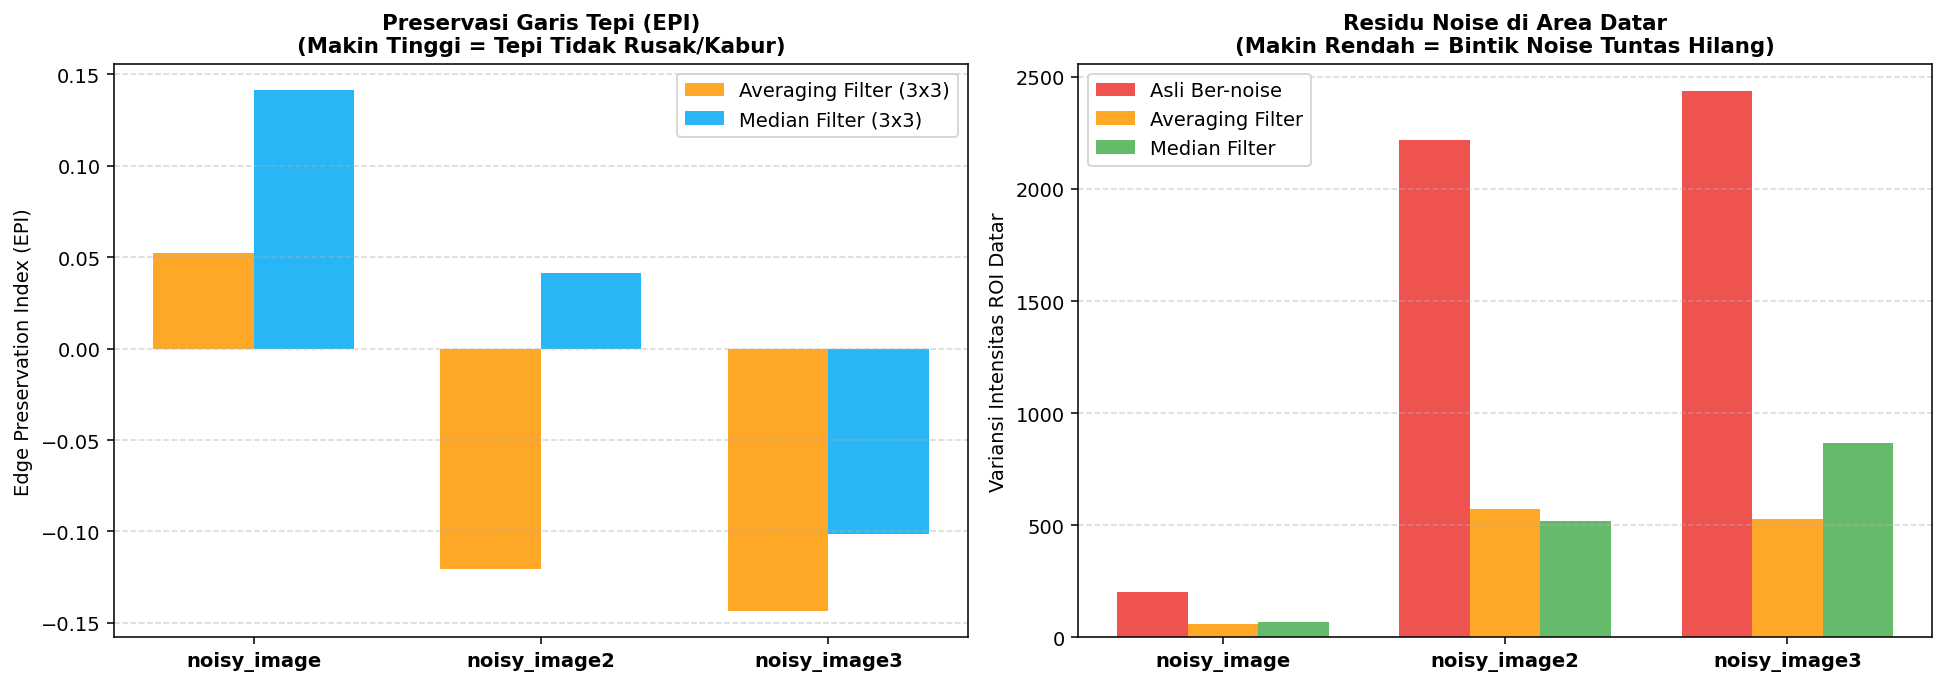

In [73]:
fig, ax_noisy = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), dpi=140)

labels = [r["name"] for r in noisy_eval_records]
x = np.arange(len(labels))
width = 0.35

# Plot 1: Edge Preservation Index (EPI)
epi_a = [r["epi_avg"] for r in noisy_eval_records]
epi_m = [r["epi_med"] for r in noisy_eval_records]

ax_noisy[0].bar(x - width/2, epi_a, width, label='Averaging Filter (3x3)', color='#FFA726')
ax_noisy[0].bar(x + width/2, epi_m, width, label='Median Filter (3x3)', color='#29B6F6')
ax_noisy[0].set_xticks(x)
ax_noisy[0].set_xticklabels(labels, fontweight='bold')
ax_noisy[0].set_ylabel('Edge Preservation Index (EPI)', fontsize=10)
ax_noisy[0].set_title('Preservasi Garis Tepi (EPI)\n(Makin Tinggi = Tepi Tidak Rusak/Kabur)', fontsize=11, fontweight='bold')
ax_noisy[0].legend()
ax_noisy[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Noise Variance di Area Homogen
var_o = [r["var_orig"] for r in noisy_eval_records]
var_a = [r["var_avg"] for r in noisy_eval_records]
var_m = [r["var_med"] for r in noisy_eval_records]

w_triple = 0.25
ax_noisy[1].bar(x - w_triple, var_o, w_triple, label='Asli Ber-noise', color='#EF5350')
ax_noisy[1].bar(x, var_a, w_triple, label='Averaging Filter', color='#FFA726')
ax_noisy[1].bar(x + w_triple, var_m, w_triple, label='Median Filter', color='#66BB6A')
ax_noisy[1].set_xticks(x)
ax_noisy[1].set_xticklabels(labels, fontweight='bold')
ax_noisy[1].set_ylabel('Variansi Intensitas ROI Datar', fontsize=10)
ax_noisy[1].set_title('Residu Noise di Area Datar\n(Makin Rendah = Bintik Noise Tuntas Hilang)', fontsize=11, fontweight='bold')
ax_noisy[1].legend()
ax_noisy[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Blurry Handling With Laplacian Filter (4 Neighbors & 8 Neighbors)

Load citra blurry

In [74]:
images_gray_blurred = {}
images_float_blurred = {}

for blur_name, file_path in dataset_paths_blurred.items():
  img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
  if img is None:
    raise FileNotFoundError(f"gagal memuat berkas: {file_path}")
  images_gray_blurred[blur_name] = img
  images_float_blurred[blur_name] = img.astype(np.float32)
  print(f"[{blur_name}] berhasil dimuat: {img.shape[0]}x{img.shape[1]} piksel")


[blurred_image] berhasil dimuat: 1365x2048 piksel
[blurred_image2] berhasil dimuat: 1365x2048 piksel
[blurred_image3] berhasil dimuat: 1365x2048 piksel


# 11. Matriks kernel laplacian

Faktor c menentukan seberapa agresif detail tepi dikembalikan ke citra asli:

g(x, y) = f(x, y) - c * ∇²f(x, y)

c = 1.0 menghasilkan kernel standar (pusat 5 atau 9).

c = 3.0 (High-Boost) mempertegas mikro-kontras pada citra yang buram pekat.

Menghasilkan kernel penajam komposit 3x3 berdasarkan faktor pengali c.

mode '4': 4-ketetanggaan (pusat = 1 + 4*c, tetangga = -c)

mode '8': 8-ketetanggaan isotropik (pusat = 1 + 8*c, tetangga = -c)

In [75]:
c_boost = 3.0

def get_laplacian_composite_kernel(c: float = 3.0, mode: str = '8') -> np.ndarray:
  if mode == '4':
    return np.array([
      [ 0.0,   -c,  0.0],
      [  -c, 1+4*c,  -c],
      [ 0.0,   -c,  0.0]
    ], dtype=np.float32)
  else:  # mode '8'
    return np.array([
      [  -c,   -c,   -c],
      [  -c, 1+8*c,  -c],
      [  -c,   -c,   -c]
    ], dtype=np.float32)

kernel_lap_4 = get_laplacian_composite_kernel(c=c_boost, mode='4')
kernel_lap_8 = get_laplacian_composite_kernel(c=c_boost, mode='8')

# 12. Convolution 2D Spatial

In [76]:
def manual_spatial_convolution(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
  h, w = image.shape
  k_h, k_w = kernel.shape
  pad_size = k_h // 2

  # tambahkan zero-padding
  padded_img = manual_zero_pad(image, pad_size=pad_size)

  # matriks penampung output
  output = np.zeros((h, w), dtype=np.float32)

  for i in range(h):
    for j in range(w):
      window = padded_img[i : i + k_h, j : j + k_w]
      val = np.sum(window * kernel)
      output[i, j] = val

  # karena kernel penajam memiliki koefisien negatif, nilai bisa < 0 atau > 255.
  clipped_output = np.clip(output, 0, 255)

  return np.round(clipped_output).astype(np.uint8)

# 13. Batch Blur Handling Filtering

In [77]:
results_blurred = {}

for b_name, img_flt in images_float_blurred.items():
  # 1. Laplacian 4-Tetangga
  t0 = time.time()
  res_l4 = manual_spatial_convolution(img_flt, kernel_lap_4)
  t_l4 = time.time() - t0
  print(f"-> Laplacian 4-Tetangga: {t_l4:.2f} detik")

  # 2. Laplacian 8-Tetangga
  t0 = time.time()
  res_l8 = manual_spatial_convolution(img_flt, kernel_lap_8)
  t_l8 = time.time() - t0
  print(f"-> Laplacian 8-Tetangga: {t_l8:.2f} detik")

  results_blurred[b_name] = {
    "lap4": res_l4,
    "lap8": res_l8,
    "time_lap4": t_l4,
    "time_lap8": t_l8
  }

-> Laplacian 4-Tetangga: 16.55 detik
-> Laplacian 8-Tetangga: 17.03 detik
-> Laplacian 4-Tetangga: 17.97 detik
-> Laplacian 8-Tetangga: 16.58 detik
-> Laplacian 4-Tetangga: 17.29 detik
-> Laplacian 8-Tetangga: 16.34 detik


# 14. Visual Matriks Komparasi 3x3 Citra Buram

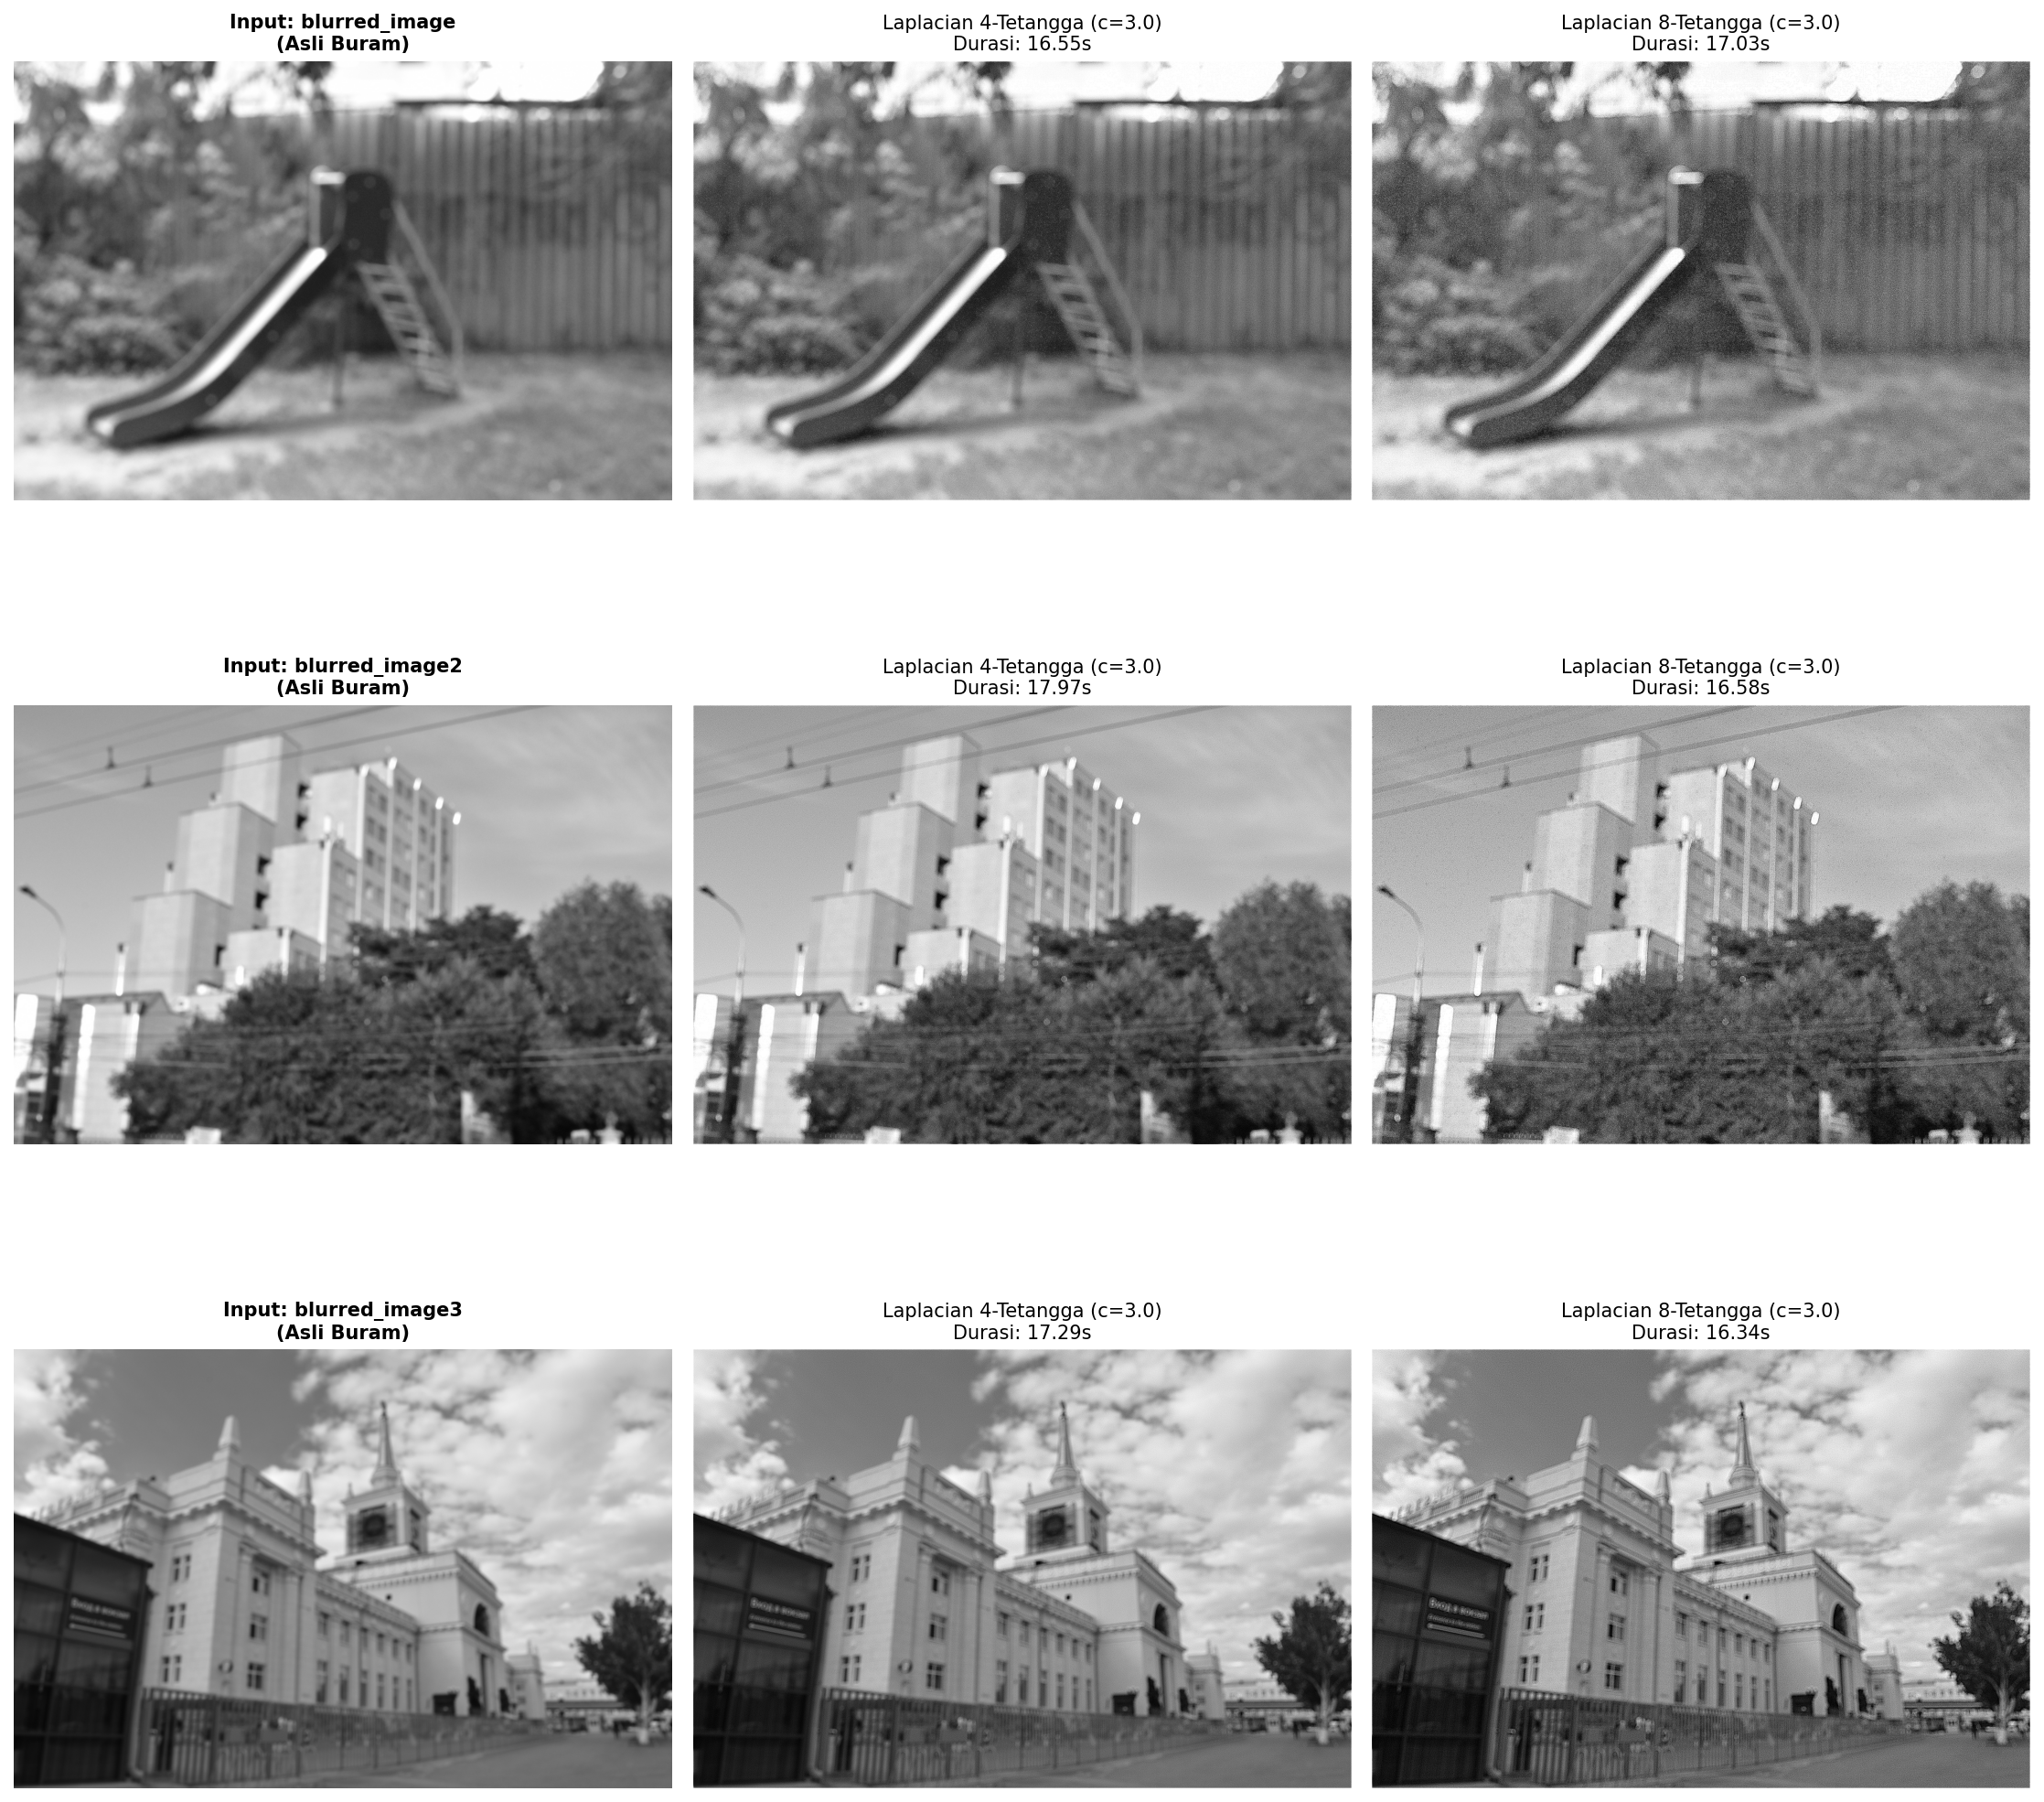

In [78]:
fig, axes_b = plt.subplots(nrows=3, ncols=3, figsize=(15, 15), dpi=150)
blur_keys = list(dataset_paths_blurred.keys())

for row_idx, b_name in enumerate(blur_keys):
  orig = images_gray_blurred[b_name]
  l4_img = results_blurred[b_name]["lap4"]
  l8_img = results_blurred[b_name]["lap8"]
  t_l4 = results_blurred[b_name]["time_lap4"]
  t_l8 = results_blurred[b_name]["time_lap8"]

  # Kolom 1: Original Buram
  axes_b[row_idx, 0].imshow(orig, cmap='gray', vmin=0, vmax=255)
  axes_b[row_idx, 0].set_title(f"Input: {b_name}\n(Asli Buram)", fontsize=10, fontweight='bold')
  axes_b[row_idx, 0].axis('off')

  # Kolom 2: Laplacian 4-Tetangga
  axes_b[row_idx, 1].imshow(l4_img, cmap='gray', vmin=0, vmax=255)
  axes_b[row_idx, 1].set_title(f"Laplacian 4-Tetangga (c={c_boost:.1f})\nDurasi: {t_l4:.2f}s", fontsize=10)
  axes_b[row_idx, 1].axis('off')

  # Kolom 3: Laplacian 8-Tetangga
  axes_b[row_idx, 2].imshow(l8_img, cmap='gray', vmin=0, vmax=255)
  axes_b[row_idx, 2].set_title(f"Laplacian 8-Tetangga (c={c_boost:.1f})\nDurasi: {t_l8:.2f}s", fontsize=10)
  axes_b[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()


# Evaluasi Kuantitatif Ketajaman Citra (Variance of Laplacian & Tenengrad)

Citra buram tidak memiliki ground-truth citra tajam asli, sehingga evaluasi objektif dilakukan dengan metrik *No-Reference Sharpness Assessment*:
1. **Variance of Laplacian (VoL)**: Menghitung dispersi frekuensi tinggi; semakin tinggi variansi, semakin kaya detail mikro tepi citra.
2. **Tenengrad Energy Criterion**: Menghitung magnitudo kuadrat gradien operator Sobel ($\sum (G_x^2 + G_y^2)$); mengukur kerapatan energi ketajaman garis tepi.

# 15. Kalkulasi & Tabel Rekapitulasi Evaluasi Penajaman Citra Buram

In [79]:
def calculate_variance_of_laplacian(image: np.ndarray) -> float:
  lap_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
  response = cv2.filter2D(image.astype(np.float32), -1, lap_kernel)
  return float(np.var(response))


def calculate_tenengrad_energy(image: np.ndarray) -> float:
  gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
  gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
  return float(np.mean((gx ** 2) + (gy ** 2)))


blur_eval_records = []
print("=" * 95)
print(f"{'CITRA':<16} | {'VARIANSI LAPLACIAN (VoL)':<28} | {'TENENGRAD GRADIENT':<24} | {'PENINGKATAN'}")
print(f"{'':<16} | {'Asli':<8} {'Lap-4':<9} {'Lap-8':<9} | {'Asli':<7} {'Lap-4':<8} {'Lap-8':<8} | {'VoL (Lap-8 vs Asli)'}")
print("-" * 95)

for b_name in blur_keys:
  orig_b = images_gray_blurred[b_name]
  l4_b = results_blurred[b_name]["lap4"]
  l8_b = results_blurred[b_name]["lap8"]

  vol_orig = calculate_variance_of_laplacian(orig_b)
  vol_l4 = calculate_variance_of_laplacian(l4_b)
  vol_l8 = calculate_variance_of_laplacian(l8_b)

  ten_orig = calculate_tenengrad_energy(orig_b)
  ten_l4 = calculate_tenengrad_energy(l4_b)
  ten_l8 = calculate_tenengrad_energy(l8_b)

  gain_vol = ((vol_l8 - vol_orig) / vol_orig) * 100.0

  blur_eval_records.append({
    "name": b_name,
    "vol_orig": vol_orig, "vol_l4": vol_l4, "vol_l8": vol_l8,
    "ten_orig": ten_orig, "ten_l4": ten_l4, "ten_l8": ten_l8,
    "gain": gain_vol
  })

  print(f"{b_name:<16} | {vol_orig:<8.1f} {vol_l4:<9.1f} {vol_l8:<9.1f} | {ten_orig:<7.1f} {ten_l4:<8.1f} {ten_l8:<8.1f} | +{gain_vol:.1f}%")

print("=" * 95)

CITRA            | VARIANSI LAPLACIAN (VoL)     | TENENGRAD GRADIENT       | PENINGKATAN
                 | Asli     Lap-4     Lap-8     | Asli    Lap-4    Lap-8    | VoL (Lap-8 vs Asli)
-----------------------------------------------------------------------------------------------
blurred_image    | 122.1    34352.3   73392.6   | 429.9   16847.4  70936.4  | +60027.2%
blurred_image2   | 101.1    27834.1   58932.0   | 462.3   14081.4  57936.0  | +58183.2%
blurred_image3   | 8.4      1966.1    6519.7    | 337.0   3124.8   13944.8  | +77592.4%


# 16. Grafik Batang Komparasi Peningkatan Ketajaman (VoL & Tenengrad)

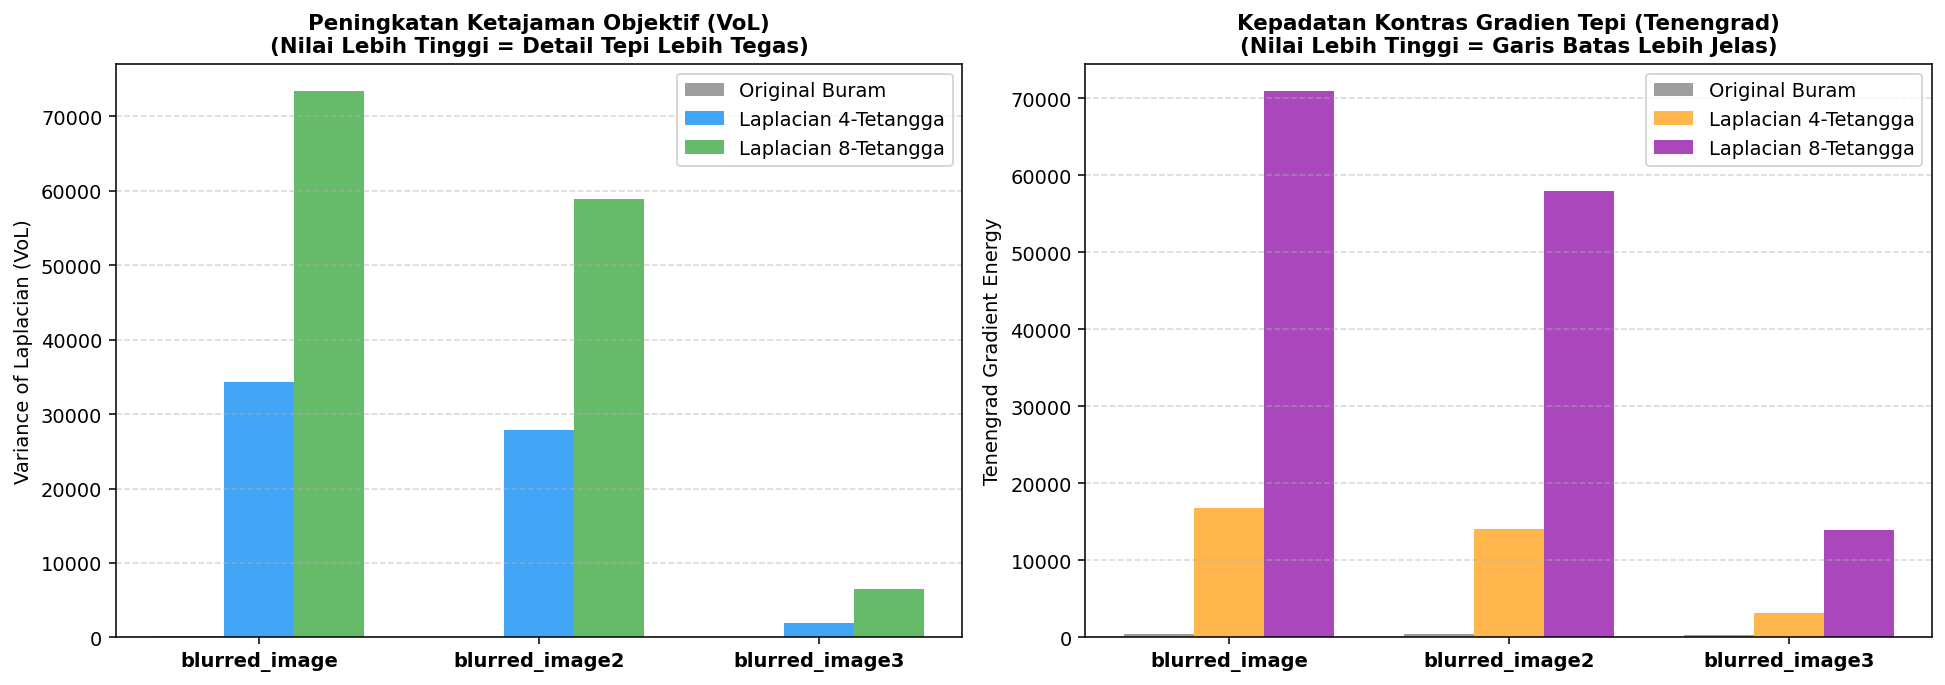

In [80]:
fig, ax_sh = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), dpi=140)
x_b = np.arange(len(blur_keys))
w = 0.25

# Plot VoL
vol_0 = [r["vol_orig"] for r in blur_eval_records]
vol_4 = [r["vol_l4"] for r in blur_eval_records]
vol_8 = [r["vol_l8"] for r in blur_eval_records]

ax_sh[0].bar(x_b - w, vol_0, w, label='Original Buram', color='#9E9E9E')
ax_sh[0].bar(x_b, vol_4, w, label='Laplacian 4-Tetangga', color='#42A5F5')
ax_sh[0].bar(x_b + w, vol_8, w, label='Laplacian 8-Tetangga', color='#66BB6A')
ax_sh[0].set_xticks(x_b)
ax_sh[0].set_xticklabels(blur_keys, fontweight='bold')
ax_sh[0].set_ylabel('Variance of Laplacian (VoL)', fontsize=10)
ax_sh[0].set_title('Peningkatan Ketajaman Objektif (VoL)\n(Nilai Lebih Tinggi = Detail Tepi Lebih Tegas)', fontsize=11, fontweight='bold')
ax_sh[0].legend()
ax_sh[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot Tenengrad
ten_0 = [r["ten_orig"] for r in blur_eval_records]
ten_4 = [r["ten_l4"] for r in blur_eval_records]
ten_8 = [r["ten_l8"] for r in blur_eval_records]

ax_sh[1].bar(x_b - w, ten_0, w, label='Original Buram', color='#9E9E9E')
ax_sh[1].bar(x_b, ten_4, w, label='Laplacian 4-Tetangga', color='#FFB74D')
ax_sh[1].bar(x_b + w, ten_8, w, label='Laplacian 8-Tetangga', color='#AB47BC')
ax_sh[1].set_xticks(x_b)
ax_sh[1].set_xticklabels(blur_keys, fontweight='bold')
ax_sh[1].set_ylabel('Tenengrad Gradient Energy', fontsize=10)
ax_sh[1].set_title('Kepadatan Kontras Gradien Tepi (Tenengrad)\n(Nilai Lebih Tinggi = Garis Batas Lebih Jelas)', fontsize=11, fontweight='bold')
ax_sh[1].legend()
ax_sh[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()